In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maitygouranga/tbmcgnet-main-segmentation")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/maitygouranga/tbmcgnet-main-segmentation


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import albumentations as A
import cv2
import warnings

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

✅ Using device: cuda


In [3]:
IMG_SIZE   = 256
BATCH_SIZE = 8
SEED       = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [4]:
class MosMedDataset(Dataset):
    def __init__(self, img_dir, mask_dir, indices=None, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.images = sorted(os.listdir(img_dir))
        self.masks  = sorted(os.listdir(mask_dir))

        if indices is not None:
            self.images = [self.images[i] for i in indices]
            self.masks  = [self.masks[i] for i in indices]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path  = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = np.array(
            Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        ) / 255.0

        mask = np.array(
            Image.open(mask_path).convert("L").resize((IMG_SIZE, IMG_SIZE))
        ) / 255.0

        mask = (mask > 0.5).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask  = augmented["mask"]

        image = torch.tensor(image).permute(2, 0, 1).float()
        mask  = torch.tensor(mask).unsqueeze(0).float()

        return image, mask


train_transform = A.Compose([
    A.Resize(256,256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=15,
        p=0.5
    ),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
])

test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
])


In [5]:
img_dir  = os.path.join('/kaggle/input/datasets/maitygouranga/tbmcgnet-main-segmentation/TBMCGNet-main/data/img')
mask_dir = os.path.join('/kaggle/input/datasets/maitygouranga/tbmcgnet-main-segmentation/TBMCGNet-main/data/mask')

IMG_SIZE   = 256
BATCH_SIZE = 8
SEED       = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [6]:
from sklearn.model_selection import StratifiedShuffleSplit

In [7]:
def compute_foreground_ratio(mask_path):
    mask = np.array(Image.open(mask_path).convert("L")) / 255.0
    return np.mean(mask > 0.5)

all_images = sorted(os.listdir(img_dir))
all_masks  = sorted(os.listdir(mask_dir))

foreground_ratios = []
for m in all_masks:
    fg = compute_foreground_ratio(os.path.join(mask_dir, m))
    foreground_ratios.append(fg)

foreground_ratios = np.array(foreground_ratios)


strata = np.digitize(
    foreground_ratios,
    bins=[0.001, 0.01, 0.05] 
)    

indices = np.arange(len(all_images))


sss1 = StratifiedShuffleSplit(
    n_splits=1, test_size=0.2, random_state=SEED
)
train_idx, temp_idx = next(sss1.split(indices, strata))
temp_strata = strata[temp_idx]


sss2 = StratifiedShuffleSplit(
    n_splits=1, test_size=0.5, random_state=SEED
)
val_sub_idx, test_sub_idx = next(
    sss2.split(temp_idx, temp_strata)
)

val_idx  = temp_idx[val_sub_idx]
test_idx = temp_idx[test_sub_idx]


train_dataset = MosMedDataset(
    img_dir, mask_dir, indices=train_idx, transform=train_transform
)
val_dataset = MosMedDataset(
    img_dir, mask_dir, indices=val_idx, transform=val_transform
)
test_dataset = MosMedDataset(
    img_dir, mask_dir, indices=test_idx, transform=test_transform
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

In [8]:
def avg_fg(idx):
    return np.mean(foreground_ratios[idx])

print("✅ Stratified Dataset Loaded Successfully!")
print(f"Total Images : {len(all_images)}")
print(f"Train        : {len(train_dataset)} | Avg FG: {avg_fg(train_idx):.4f}")
print(f"Validation   : {len(val_dataset)}   | Avg FG: {avg_fg(val_idx):.4f}")
print(f"Test         : {len(test_dataset)}  | Avg FG: {avg_fg(test_idx):.4f}")

✅ Stratified Dataset Loaded Successfully!
Total Images : 2000
Train        : 1600 | Avg FG: 0.1942
Validation   : 200   | Avg FG: 0.1992
Test         : 200  | Avg FG: 0.1940


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


In [10]:
import torch
import torch.nn as nn
import math


class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)



class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        B, N, C = x.shape
        device = x.device

        position = torch.arange(N, device=device).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, C, 2, device=device) * (-math.log(10000.0) / C)
        )

        pe = torch.zeros(N, C, device=device)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        return x + pe.unsqueeze(0)



class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=512, embed_dim=768):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=1,stride=1)

    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)  # (B, N, C)
        return x, H, W



class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=12, mlp_dim=2048):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, dim)
        )

    def forward(self, x):
        attn_out, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x



class TransformerEncoder(nn.Module):
    def __init__(self, depth=4, dim=768):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerBlock(dim) for _ in range(depth)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x



class DecoderBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_c, out_c, 2, stride=2)
        self.conv = ConvBlock(in_c, out_c)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)



# ---------------------------
class TransUNet(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()

        
        self.enc1 = ConvBlock(3, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)
        self.enc4 = ConvBlock(256, 512)
        self.pool = nn.MaxPool2d(2)

        
        self.patch_embed = PatchEmbedding(512, 768)
        self.pos_enc = SinusoidalPositionalEncoding(768)
        self.transformer = TransformerEncoder(depth=4, dim=768)

        
        self.proj_back = nn.Conv2d(768, 512, 1)

        
        self.dec1 = DecoderBlock(512, 256)
        self.dec2 = DecoderBlock(256, 128)
        self.dec3 = DecoderBlock(128, 64)

        self.final = nn.Conv2d(64, num_classes, 1)

        
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))
        x4 = self.enc4(self.pool(x3))

        
        t, H, W = self.patch_embed(x4)

        
        t = self.pos_enc(t)

       
        t = self.transformer(t)

        
        B, N, C = t.shape
        t = t.transpose(1, 2).view(B, C, H, W)
        t = self.proj_back(t)

       
        d1 = self.dec1(t, x3)
        d2 = self.dec2(d1, x2)
        d3 = self.dec3(d2, x1)

        out = self.final(d3)

        return self.sigmoid(out)



In [11]:
unet_model=TransUNet(num_classes=1)
print(unet_model)

TransUNet(
  (enc1): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (enc2): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (enc3): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (

In [12]:
from torchinfo import summary
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = TransUNet(num_classes=1).to(device)

summary(
    model,
    input_size=(4, 3, 256, 256),   # (batch, channels, height, width)
    col_names=["input_size", "output_size", "num_params"],
    depth=3
)

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
TransUNet                                     [4, 3, 256, 256]          [4, 1, 256, 256]          --
├─ConvBlock: 1-1                              [4, 3, 256, 256]          [4, 64, 256, 256]         --
│    └─Sequential: 2-1                        [4, 3, 256, 256]          [4, 64, 256, 256]         --
│    │    └─Conv2d: 3-1                       [4, 3, 256, 256]          [4, 64, 256, 256]         1,792
│    │    └─BatchNorm2d: 3-2                  [4, 64, 256, 256]         [4, 64, 256, 256]         128
│    │    └─ReLU: 3-3                         [4, 64, 256, 256]         [4, 64, 256, 256]         --
│    │    └─Conv2d: 3-4                       [4, 64, 256, 256]         [4, 64, 256, 256]         36,928
│    │    └─BatchNorm2d: 3-5                  [4, 64, 256, 256]         [4, 64, 256, 256]         128
│    │    └─ReLU: 3-6                         [4, 64, 256, 256]         [4, 6

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, smooth=1e-5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, preds, targets):
        # preds should be probabilities (after sigmoid)
        preds = preds.view(-1)
        targets = targets.view(-1)

        # --------------------
        # FOCAL LOSS
        # --------------------
        bce_loss = F.binary_cross_entropy(preds, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        focal_loss = focal_loss.mean()

        # --------------------
        # DICE LOSS
        # --------------------
        intersection = (preds * targets).sum()
        dice_loss = 1 - (2 * intersection + self.smooth) / \
                        (preds.sum() + targets.sum() + self.smooth)

        # --------------------
        # COMBINED LOSS
        # --------------------
        return 0.5 * focal_loss + 0.5 * dice_loss

In [14]:
def dice_coef(y_true,y_pred,smooth=1e-5):
    y_true_f=y_true.view(-1)
    y_pred_f=y_pred.view(-1)

    inter=(y_true_f*y_pred_f).sum()
    total_f=y_true_f.sum()+y_pred_f.sum()
    return (((2*inter)+smooth)/total_f+smooth)

In [15]:
def iou_score(preds, masks, threshold=0.5, smooth=1e-6):

    preds_bin = (preds > threshold).float()
    masks_bin = (masks > threshold).float()

    intersection = (preds_bin * masks_bin).sum()
    union = preds_bin.sum() + masks_bin.sum() - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou

In [16]:
def train_model(model, train_loader, val_loader, epochs=50):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    criterion = FocalDiceLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    
    train_losses, val_losses = [], []
    train_dice_scores, val_dice_scores = [], []
    train_iou_scores, val_iou_scores = [], []

    best_val_loss = float("inf")
    best_epoch = 0
    best_model_weights = None

    for epoch in range(epochs):

        
        model.train()
        train_loss = train_dice = train_iou = 0

        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


            train_loss += loss.item()
            train_dice += dice_coef(masks, preds).item()
            train_iou += iou_score(preds, masks).item()

        
        model.eval()
        val_loss = val_dice = val_iou = 0

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images, masks = images.to(device), masks.to(device)

                preds = model(images)
                val_loss += criterion(preds, masks).item()
                val_dice += dice_coef(masks, preds).item()
                val_iou += iou_score(preds, masks).item()

        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss / len(val_loader)
        avg_train_dice = train_dice / len(train_loader)
        avg_val_dice   = val_dice / len(val_loader)
        avg_train_iou  = train_iou / len(train_loader)
        avg_val_iou    = val_iou / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_dice_scores.append(avg_train_dice)
        val_dice_scores.append(avg_val_dice)
        train_iou_scores.append(avg_train_iou)
        val_iou_scores.append(avg_val_iou)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"Train Dice: {avg_train_dice:.4f} | Val Dice: {avg_val_dice:.4f}")
        print(f"Train IoU : {avg_train_iou:.4f} | Val IoU : {avg_val_iou:.4f}")

        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "best_unet_monu.pth")
            print(f" Best model saved (Epoch {epoch+1}, Val Loss {best_val_loss:.4f})")

    
    model.load_state_dict(best_model_weights)

    print("\n Training Completed!")
    print(f" Best Epoch: {best_epoch}")
    print(f"✔ Best Val Loss: {best_val_loss:.4f}")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_dice": train_dice_scores,
        "val_dice": val_dice_scores,
        "train_iou": train_iou_scores,
        "val_iou": val_iou_scores,
    }


In [17]:
def plot_training(history):
    plt.figure(figsize=(17, 4))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(history["train_losses"], label="Train Loss")
    plt.plot(history["val_losses"], label="Val Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Dice
    plt.subplot(1, 3, 2)
    plt.plot(history["train_dice"], label="Train Dice")
    plt.plot(history["val_dice"], label="Val Dice")
    plt.title("Dice Curve")
    plt.legend()

    # IoU
    plt.subplot(1, 3, 3)
    plt.plot(history["train_iou"], label="Train IoU")
    plt.plot(history["val_iou"], label="Val IoU")
    plt.title("IoU Curve")
    plt.legend()

    plt.show()

In [18]:
import torch
import copy
# other imports...

Epoch 1/200 [Val]: 100%|██████████| 25/25 [00:09<00:00,  2.72it/s]



Epoch 1/200
Train Loss: 0.2079 | Val Loss: 0.1592
Train Dice: 0.6103 | Val Dice: 0.6961
Train IoU : 0.6795 | Val IoU : 0.7916
 Best model saved (Epoch 1, Val Loss 0.1592)


Epoch 2/200 [Val]: 100%|██████████| 25/25 [00:09<00:00,  2.69it/s]



Epoch 2/200
Train Loss: 0.1521 | Val Loss: 0.1234
Train Dice: 0.7148 | Val Dice: 0.7657
Train IoU : 0.7742 | Val IoU : 0.8186
 Best model saved (Epoch 2, Val Loss 0.1234)


Epoch 3/200 [Val]: 100%|██████████| 25/25 [00:09<00:00,  2.68it/s]


...


Epoch 198/200
Train Loss: 0.0378 | Val Loss: 0.0412
Train Dice: 0.9375 | Val Dice: 0.9353
Train IoU : 0.8929 | Val IoU : 0.8856


Epoch 199/200 [Val]: 100%|██████████| 25/25 [00:09<00:00,  2.69it/s]



Epoch 199/200
Train Loss: 0.0375 | Val Loss: 0.0417
Train Dice: 0.9380 | Val Dice: 0.9337
Train IoU : 0.8936 | Val IoU : 0.8834


Epoch 200/200 [Val]: 100%|██████████| 25/25 [00:09<00:00,  2.69it/s]



Epoch 200/200
Train Loss: 0.0371 | Val Loss: 0.0410
Train Dice: 0.9386 | Val Dice: 0.9354
Train IoU : 0.8947 | Val IoU : 0.8863

 Training Completed!
 Best Epoch: 168
✔ Best Val Loss: 0.0405


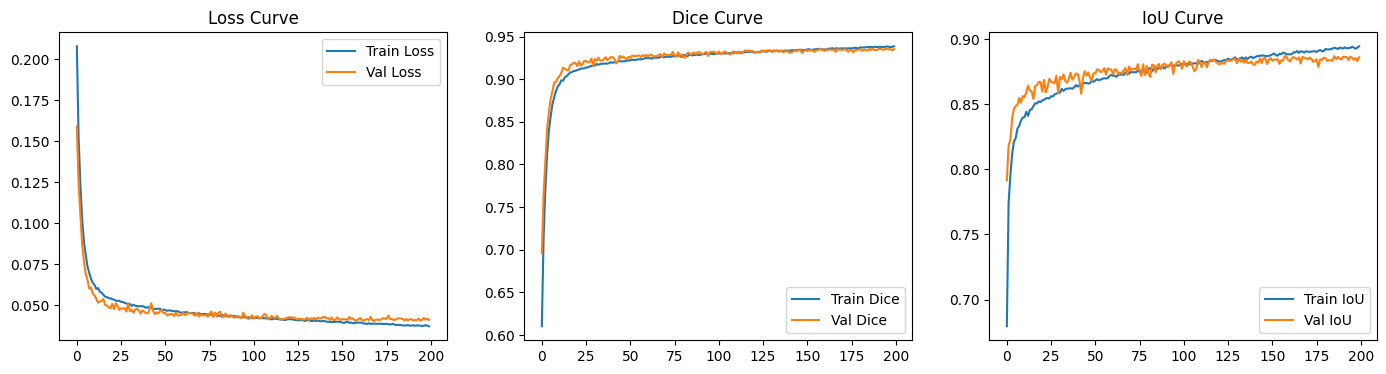

In [19]:
device="cuda" if torch.cuda.is_available() else "cpu"

model=TransUNet(num_classes=1).to(device)

history=train_model(model,train_loader,val_loader,epochs=200)
plot_training(history)

📥 Loading best model...
🧪 Evaluating on test set...


Evaluating Test Set: 100%|██████████| 25/25 [00:09<00:00,  2.69it/s]



🎯 TEST SET EVALUATION
✅ Dice Coefficient: 0.9372
✅ IoU (Jaccard):    0.8818

📊 Generating visualizations...


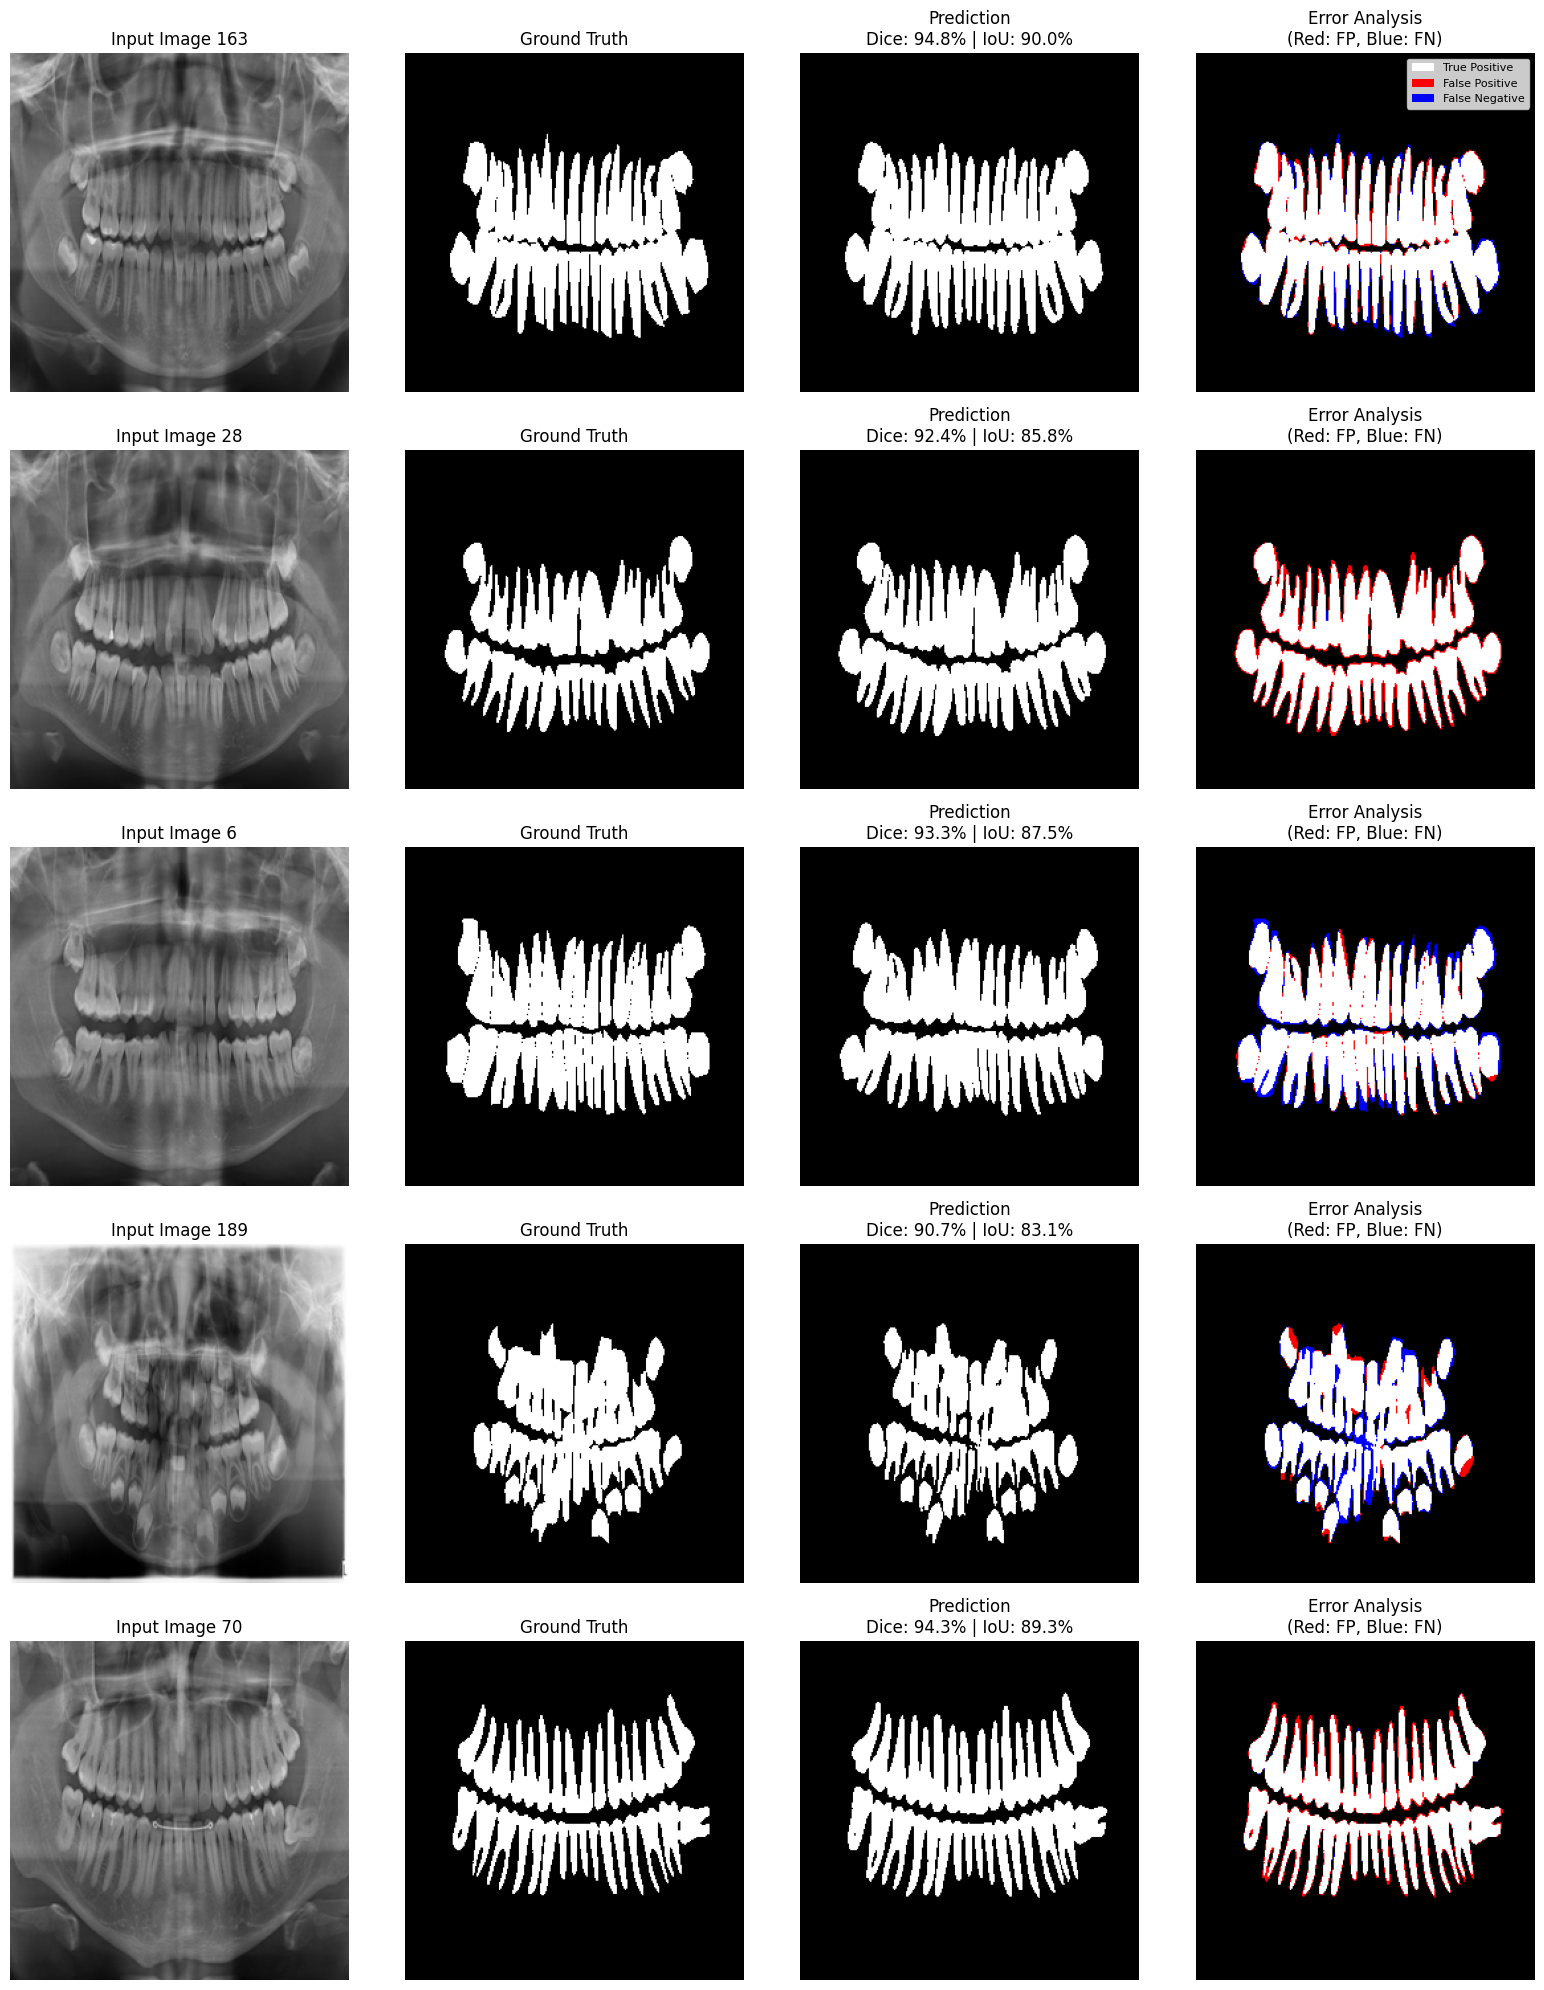


🎉 Evaluation completed successfully!


In [20]:
def iou_coef(y_true, y_pred, smooth=1e-5):
    """
    Intersection over Union (IoU) metric for binary masks.
    """
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    intersection = (y_true_f * y_pred_f).sum()
    union = y_true_f.sum() + y_pred_f.sum() - intersection
    return (intersection + smooth) / (union + smooth)

# Load the best model
print("📥 Loading best model...")
model.load_state_dict(torch.load("best_unet_monu.pth", map_location=device))
model.eval()

# Initialize accumulators for metrics
test_dice, test_iou = 0, 0

print("🧪 Evaluating on test set...")

# Loop through test data
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Evaluating Test Set"):
        images, masks = images.to(device), masks.to(device)
        preds = model(images)
        preds_bin = (preds > 0.5).float()   # threshold at 0.5

        # Accumulate metrics
        test_dice += dice_coef(masks, preds_bin).item()
        test_iou += iou_coef(masks, preds_bin).item()

# Average metrics
num_batches = len(test_loader)
avg_test_dice = test_dice / num_batches
avg_test_iou = test_iou / num_batches

# Print simplified results
print("\n" + "="*40)
print("🎯 TEST SET EVALUATION")
print("="*40)
print(f"✅ Dice Coefficient: {avg_test_dice:.4f}")
print(f"✅ IoU (Jaccard):    {avg_test_iou:.4f}")
print("="*40)

# =============================================================
# Simplified Visualization (Only Dice and IoU)
# =============================================================

def dice_coef_single(y_true, y_pred, smooth=1e-5):
    """Compute Dice coefficient for one pair of masks"""
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

def iou_coef_single(y_true, y_pred, smooth=1e-5):
    """Compute IoU for one pair of masks"""
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return intersection / (union + smooth)

def visualize_predictions_simple(model, dataset, num_samples=5, threshold=0.5):
    """
    Simplified visualization with dice, iou and error analysis
    """
    indices = random.sample(range(len(dataset)), num_samples)
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 4))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        image, mask = dataset[idx]

        with torch.no_grad():
            pred_prob = model(image.unsqueeze(0).to(device)).cpu().squeeze().numpy()

        pred_mask = (pred_prob > threshold).astype(np.uint8)
        true_mask = mask.squeeze().numpy().astype(np.uint8)
        
        # Compute metrics
        dice_score = dice_coef_single(true_mask, pred_mask) * 100
        iou_score = iou_coef_single(true_mask, pred_mask) * 100
        
        # Create error map (FP: red, FN: blue, TP: white, TN: black)
        error_map = np.zeros((*true_mask.shape, 3), dtype=np.uint8)
        true_positive = (true_mask == 1) & (pred_mask == 1)
        false_positive = (true_mask == 0) & (pred_mask == 1)
        false_negative = (true_mask == 1) & (pred_mask == 0)
        
        error_map[true_positive] = [255, 255, 255]  # White for TP
        error_map[false_positive] = [255, 0, 0]     # Red for FP
        error_map[false_negative] = [0, 0, 255]     # Blue for FN

        # Plot 1: Original Image
        axes[i, 0].imshow(image.permute(1, 2, 0) if image.shape[0] == 3 else image.squeeze(), cmap='gray')
        axes[i, 0].set_title(f"Input Image {idx}")
        axes[i, 0].axis("off")
        
        # Plot 2: Ground Truth
        axes[i, 1].imshow(true_mask, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")
        
        # Plot 3: Predicted Mask
        axes[i, 2].imshow(pred_mask, cmap="gray")
        axes[i, 2].set_title(f"Prediction\nDice: {dice_score:.1f}% | IoU: {iou_score:.1f}%")
        axes[i, 2].axis("off")
        
        # Plot 4: Error Analysis
        axes[i, 3].imshow(error_map)
        axes[i, 3].set_title("Error Analysis\n(Red: FP, Blue: FN)")
        axes[i, 3].axis("off")
        
        # Add legend for error map (only for first row)
        if i == 0:
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='white', label='True Positive'),
                Patch(facecolor='red', label='False Positive'),
                Patch(facecolor='blue', label='False Negative')
            ]
            axes[i, 3].legend(handles=legend_elements, loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()
    
    return indices

# Run simplified visualization
print("\n📊 Generating visualizations...")
sampled_indices = visualize_predictions_simple(model, test_dataset, num_samples=5)

print("\n🎉 Evaluation completed successfully!")